In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D

# # GenEval
# methods = ["SD-1.5", "SPM_reproduce", "CoDE", "SPM_reproduce linear CoDE (0.5)"]
# metrics = ["PickScore", "HPSv2", "CLIPScore", "GenEval", "CLIP-IQA", "DeQA" ]
# data_dict = {
#     "SD-1.5": {
#         "PickScore": 21.627,
#         "HPSv2": 0.2772,
#         "ImageReward": -0.1859,
#         "CLIPScore": 31.97,
#         "GenEval": 0.4180,
#         "CLIP-IQA": 0.6945,
#         "DeQA": 3.758
#     },
#     "SPM_reproduce": {
#         "PickScore": 21.856,
#         "HPSv2": 0.2826,
#         "ImageReward": 0.1834,
#         "CLIPScore": 32.25,
#         "GenEval": 0.4681,
#         "CLIP-IQA": 0.6245,
#         "DeQA": 3.291
#     },
#     "CoDE": {
#         "PickScore": 21.676,
#         "HPSv2": 0.2778,
#         "ImageReward": -0.1894,
#         "CLIPScore": 31.92,
#         "GenEval": 0.4272,
#         "CLIP-IQA": 0.6964,
#         "DeQA": 3.810
#     },
#     "SPM_reproduce linear CoDE (0.5)": {
#         "PickScore": 21.866,
#         "HPSv2": 0.2817,
#         "ImageReward": 0.0304,
#         "CLIPScore": 32.14,
#         "GenEval": 0.4615,
#         "CLIP-IQA": 0.6760,
#         "DeQA": 3.637
#     }
# }

# # Pick-a-pic (lora_weight: 1.0)
# methods = ["SD-1.5", "SPM_reproduce", "CoDE_15", "SPM_reproduce concat CoDE_15 (1.0)"]
# metrics = ["PickScore", "HPSv2", "CLIPScore", "GenEval", "CLIP-IQA", "DeQA" ]
# data_dict = {
#     "SD-1.5": {
#         "PickScore": 20.526,
#         "HPSv2": 0.2671,
#         "ImageReward": 0.1131,
#         "CLIPScore": 31.55,
#         "GenEval": 0.4180,
#         "CLIP-IQA": 0.6593,
#         "DeQA": 3.528
#     },
#     "SPM_reproduce": {
#         "PickScore": 21.092,
#         "HPSv2": 0.2752,
#         "ImageReward": 0.5343,
#         "CLIPScore": 32.06,
#         "GenEval": 0.4681,
#         "CLIP-IQA": 0.5918,
#         "DeQA": 3.276
#     },
#     "CoDE_15": {
#         "PickScore": 20.597,
#         "HPSv2": 0.2671,
#         "ImageReward": 0.1586,
#         "CLIPScore": 31.77,
#         "GenEval": 0.4248,
#         "CLIP-IQA": 0.6737,
#         "DeQA": 3.564
#     },
#     "SPM_reproduce concat CoDE_15 (1.0)": {
#         "PickScore": 21.135,
#         "HPSv2": 0.2750,
#         "ImageReward": 0.5184,
#         "CLIPScore": 32.08,
#         "GenEval": 0.4703,
#         "CLIP-IQA": 0.6072,
#         "DeQA": 3.346
#     }
# }

# Pick-a-pic (lora_weight: 1.0)
methods = [ "SD-1.5", "SPM_reproduce", "CoDE_15", "SPM_reproduce ties_svd CoDE_15 (1.0)"]
metrics = [ "PickScore", "HPSv2", "CLIPScore", "VQAScore", "CLIP-IQA", "DeQA", "Aesthetic-v2-5", "VILA" ]
data_dict = {
    "SD-1.5": {
        "PickScore": 20.526,
        "HPSv2": 0.2671,
        "ImageReward": 0.1131,
        "CLIPScore": 31.55,
        "VQAScore": 0.6253,
        "CLIP-IQA": 0.6593,
        "DeQA": 3.528,
        "Aesthetic-v2-5": 4.4374,
        "VILA": 0.4815
    },
    "SPM_reproduce": {
        "PickScore": 21.092,
        "HPSv2": 0.2752,
        "ImageReward": 0.5343,
        "CLIPScore": 32.06,
        "VQAScore": 0.6555,
        "CLIP-IQA": 0.5918,
        "DeQA": 3.276,
        "Aesthetic-v2-5": 4.4676,
        "VILA": 0.4696
    },
    "CoDE_15": {
        "PickScore": 20.597,
        "HPSv2": 0.2671,
        "ImageReward": 0.1586,
        "CLIPScore": 31.77,
        "VQAScore": 0.6415,
        "CLIP-IQA": 0.6737,
        "DeQA": 3.564,
        "Aesthetic-v2-5": 4.4751,
        "VILA": 0.5031
    },
    "SPM_reproduce concat CoDE_15 (1.0)": {
        "PickScore": 21.135,
        "HPSv2": 0.2750,
        "ImageReward": 0.5184,
        "CLIPScore": 32.08,
        "VQAScore": 0.6598,
        "CLIP-IQA": 0.6072,
        "DeQA": 3.346,
        "Aesthetic-v2-5": 4.5309,
        "VILA": 0.4960
    },
    "SPM_reproduce ties_svd CoDE_15 (1.0)": {
        "PickScore": 21.050,
        "HPSv2": 0.2742,
        "ImageReward": 0.4955,
        "CLIPScore": 32.24,
        "VQAScore": 0.6559,
        "CLIP-IQA": 0.6277,
        "DeQA": 3.399,
        "Aesthetic-v2-5": 4.5198,
        "VILA": 0.4960
    }
}



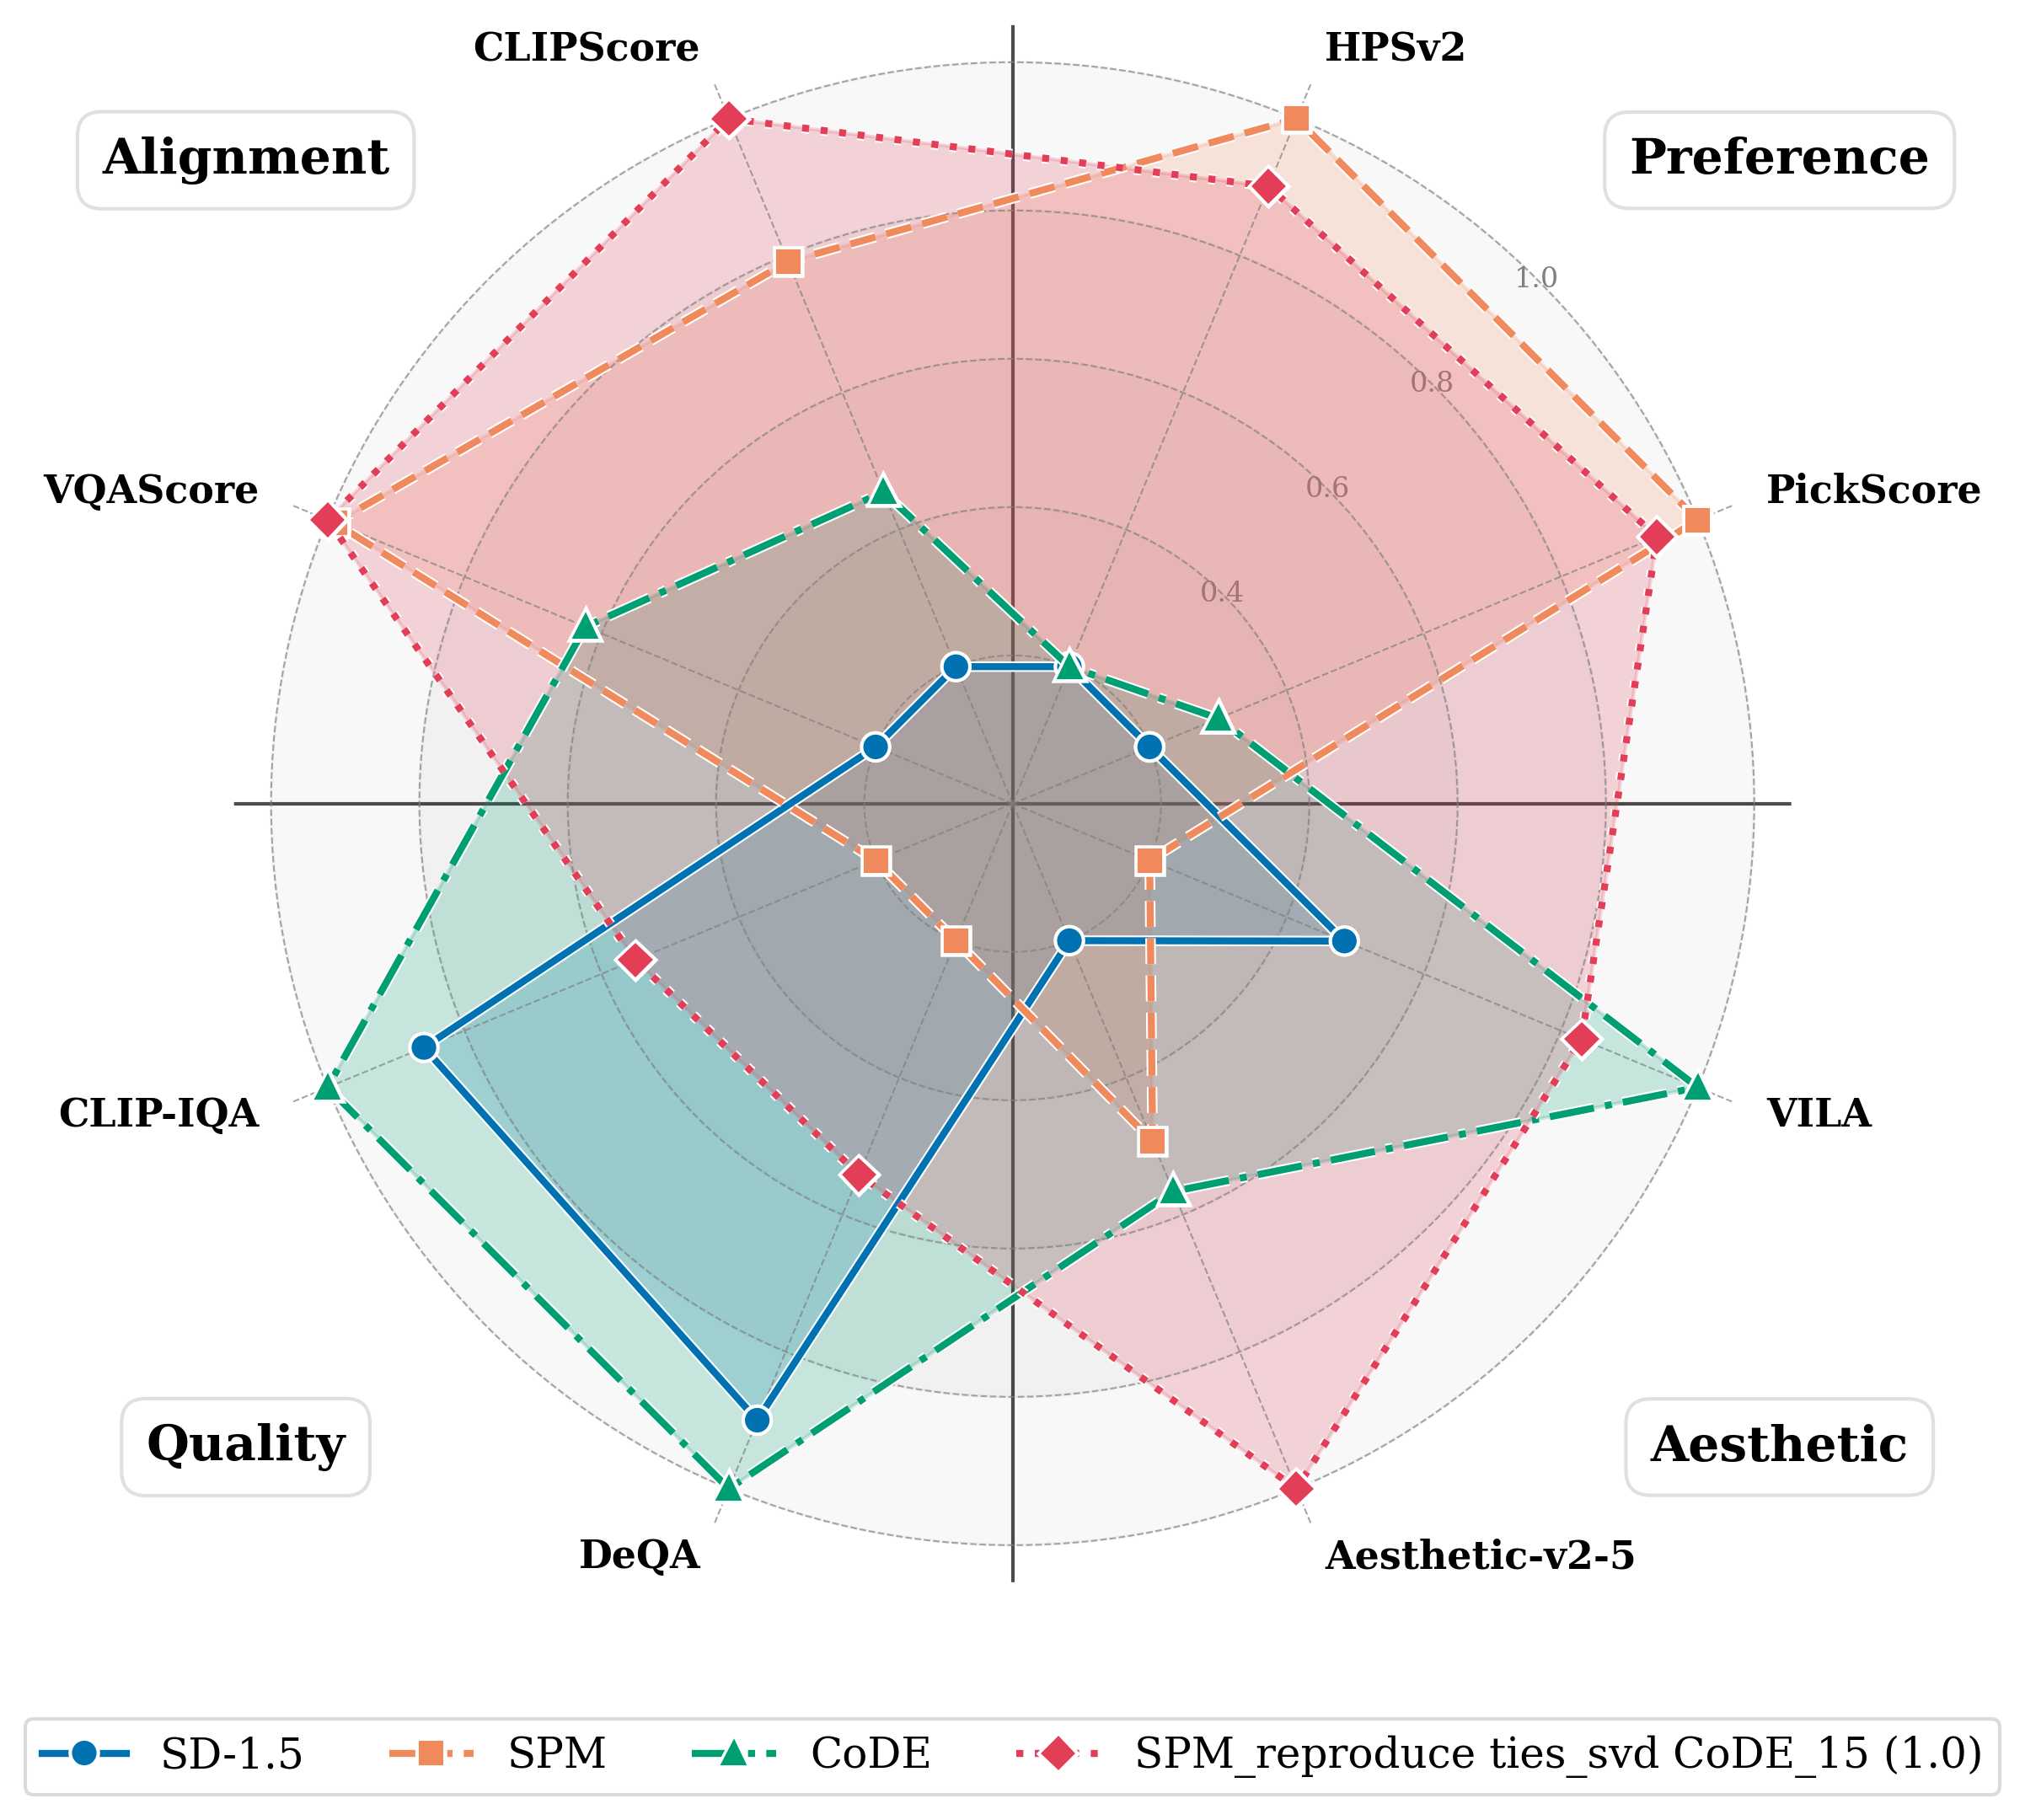

In [36]:
# Claude-Opus-4.1
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.patheffects as PathEffects
from matplotlib.patches import Circle

# 创建DataFrame
df = pd.DataFrame(columns=metrics)
for method in methods:
    df.loc[method] = [data_dict[method][metric] for metric in metrics]

# --- 2. Define the Grouping and Custom Angles ---

# Define the order of metrics to match the quadrant layout
ordered_metrics = [
    # Quadrant 1: Preference
    'HPSv2', 'PickScore',
    # Quadrant 2: Alignment
    'CLIPScore', 'VQAScore',
    # Quadrant 3: Quality
    'CLIP-IQA', 'DeQA',
    # Quadrant 4: Aesthetic
    'Aesthetics-v2-5', 'VILA'
]

# MODIFIED: Updated all angles to be symmetrical within their quadrants
degree_angles = [
    # Quadrant 1 (symmetrical around 45°)
    22.5, 67.5,
    # Quadrant 2 (symmetrical around 135°)
    112.5, 157.5,
    # Quadrant 3 (symmetrical around 225°)
    202.5, 247.5,
    # Quadrant 4 (symmetrical around 315°)
    292.5, 337.5
]

# Convert degrees to radians for Matplotlib
angles = [np.deg2rad(angle) for angle in degree_angles]
# Close the loop for plotting
angles_closed = angles + angles[:1]


# 数据标准化
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), index=df.index, columns=df.columns)

# 设置图表样式 - 使用更适合学术论文的样式
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Palatino', 'serif'],
    'font.size': 12,
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'axes.edgecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black'
})

# 创建图表
fig = plt.figure(figsize=(10, 8), facecolor='white', dpi=300)
ax = fig.add_subplot(111, polar=True)

# 使用适合学术论文的配色方案
colors = ['#0072B2', '#f08a5d', '#009E73', '#e23e57',] # colors = ['#0072B2', '#D55E00', '#009E73', '#CC79A7']
markers = ['o', 's', '^', 'D']
line_styles = ['-', '--', '-.', ':']
alphas = [0.2, 0.2, 0.2, 0.2]

# 简化方法名称以提高可读性
method_names = {
    "SD-1.5": "SD-1.5",
    "SPM_reproduce": "SPM",
    "CoDE_15": "CoDE",
    "SPM_reproduce concat CoDE_15 (1.0)": "SPM+CoDE"
}

# 设置最小值为0.2，最大值为1
min_value = 0.2
max_value = 1.0

# 调整数据范围从0.2到1.0
df_adjusted = df_scaled * (max_value - min_value) + min_value

# 添加横轴和纵轴将雷达图分成四个象限
max_r = 1.05  # 与ax.set_ylim(0, 1.05)保持一致

# 水平轴 (0° 和 180°)
ax.plot([0, 0], [0, max_r], color='black', linestyle='-', linewidth=1, alpha=0.7, zorder=1)
ax.plot([np.pi, np.pi], [0, max_r], color='black', linestyle='-', linewidth=1, alpha=0.7, zorder=1)

# 垂直轴 (90° 和 270°)
ax.plot([np.pi/2, np.pi/2], [0, max_r], color='black', linestyle='-', linewidth=1, alpha=0.7, zorder=1)
ax.plot([3*np.pi/2, 3*np.pi/2], [0, max_r], color='black', linestyle='-', linewidth=1, alpha=0.7, zorder=1)

# 添加象限标签
quadrant_labels = ['Preference', 'Alignment', 'Quality', 'Aesthetic']
quadrant_angles = [2*np.pi/9, 7*np.pi/9, 11*np.pi/9, 16*np.pi/9]  # 45°, 135°, 225°, 315°
quadrant_radius = 1.35

for i, (label, angle) in enumerate(zip(quadrant_labels, quadrant_angles)):
    ax.text(angle, quadrant_radius, label, 
            ha='center', va='center', 
            fontsize=14, fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='lightgray', boxstyle='round,pad=0.5'))

# 添加背景圆环 - 从0.2开始
# 这里的实现非常棒，无需改动
for i in range(1, 5):
    # 注意：这里的半径计算应该是基于0-1的范围，再乘以区间的宽度
    radius = min_value + (i/4) * (max_value - min_value) # 我把 i/5 改成了 i/4，这样可以均分为 0.4, 0.6, 0.8, 1.0
    circle = Circle((0, 0), radius, transform=ax.transData._b, 
                    fill=True, alpha=0.05, color='gray', zorder=0)
    ax.add_artist(circle)
    # 添加刻度值标签
    ax.text(np.pi/4, radius, f'{radius:.1f}', ha='center', va='center', fontsize=8, color='gray', zorder=1) # 将标签放在了上方，避免重叠


# 添加每个方法的数据
for i, method in enumerate(methods):
    values = df_adjusted.loc[method].values.tolist()
    values += values[:1]  # 闭合雷达图
    
    # 绘制线条和填充
    ax.plot(angles_closed, values, markers[i] + line_styles[i], linewidth=2, color=colors[i], 
            label=method_names.get(method, method), markersize=6,
            path_effects=[PathEffects.withStroke(linewidth=3, foreground='white')])
    ax.fill(angles_closed, values, color=colors[i], alpha=alphas[i])

# --- 5. Formatting Grid and Labels ---
# Set y-axis to a 0-1 range and format grid labels
ax.set_ylim(0, 1.05)
ax.set_yticklabels([]) 
ax.set_rlabel_position(180) # Move radial labels to the left to avoid overlap

# Set custom positions for the metric labels (the x-ticks)
ax.set_xticks(angles)

# 调整标签位置，使其更加清晰
for i, label in enumerate(metrics):
    angle = angles[i]
    # 根据角度调整标签位置，使其更加整齐
    if angle == 0:
        ha, va = "center", "center"
        ax.text(angle, 1.1, label, ha=ha, va=va, fontsize=11, fontweight='bold')
    elif 0 < angle < np.pi/2:
        ha, va = "left", "center"
        ax.text(angle, 1.1, label, ha=ha, va=va, fontsize=11, fontweight='bold')
    elif angle == np.pi/2:
        ha, va = "center", "center"
        ax.text(angle, 1.1, label, ha=ha, va=va, fontsize=11, fontweight='bold')
    elif np.pi/2 < angle < np.pi:
        ha, va = "right", "center"
        ax.text(angle, 1.1, label, ha=ha, va=va, fontsize=11, fontweight='bold')
    elif angle == np.pi:
        ha, va = "center", "center"
        ax.text(angle, 1.1, label, ha=ha, va=va, fontsize=11, fontweight='bold')
    elif np.pi < angle < 3*np.pi/2:
        ha, va = "right", "center"
        ax.text(angle, 1.1, label, ha=ha, va=va, fontsize=11, fontweight='bold')
    elif angle == 3*np.pi/2:
        ha, va = "center", "center"
        ax.text(angle, 1.1, label, ha=ha, va=va, fontsize=11, fontweight='bold')
    else:
        ha, va = "left", "center"
        ax.text(angle, 1.1, label, ha=ha, va=va, fontsize=11, fontweight='bold')


# Hide the default tick labels that we are replacing
ax.set_xticklabels([])

# --- 6. Final Touches ---

# Add a clean legend below the chart
legend = plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15),
                    ncol=4, frameon=True, fontsize=12)
legend.get_frame().set_edgecolor('lightgray')

# Style the grid lines
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
ax.spines['polar'].set_visible(False) # Hide the outer circle spine

plt.show()

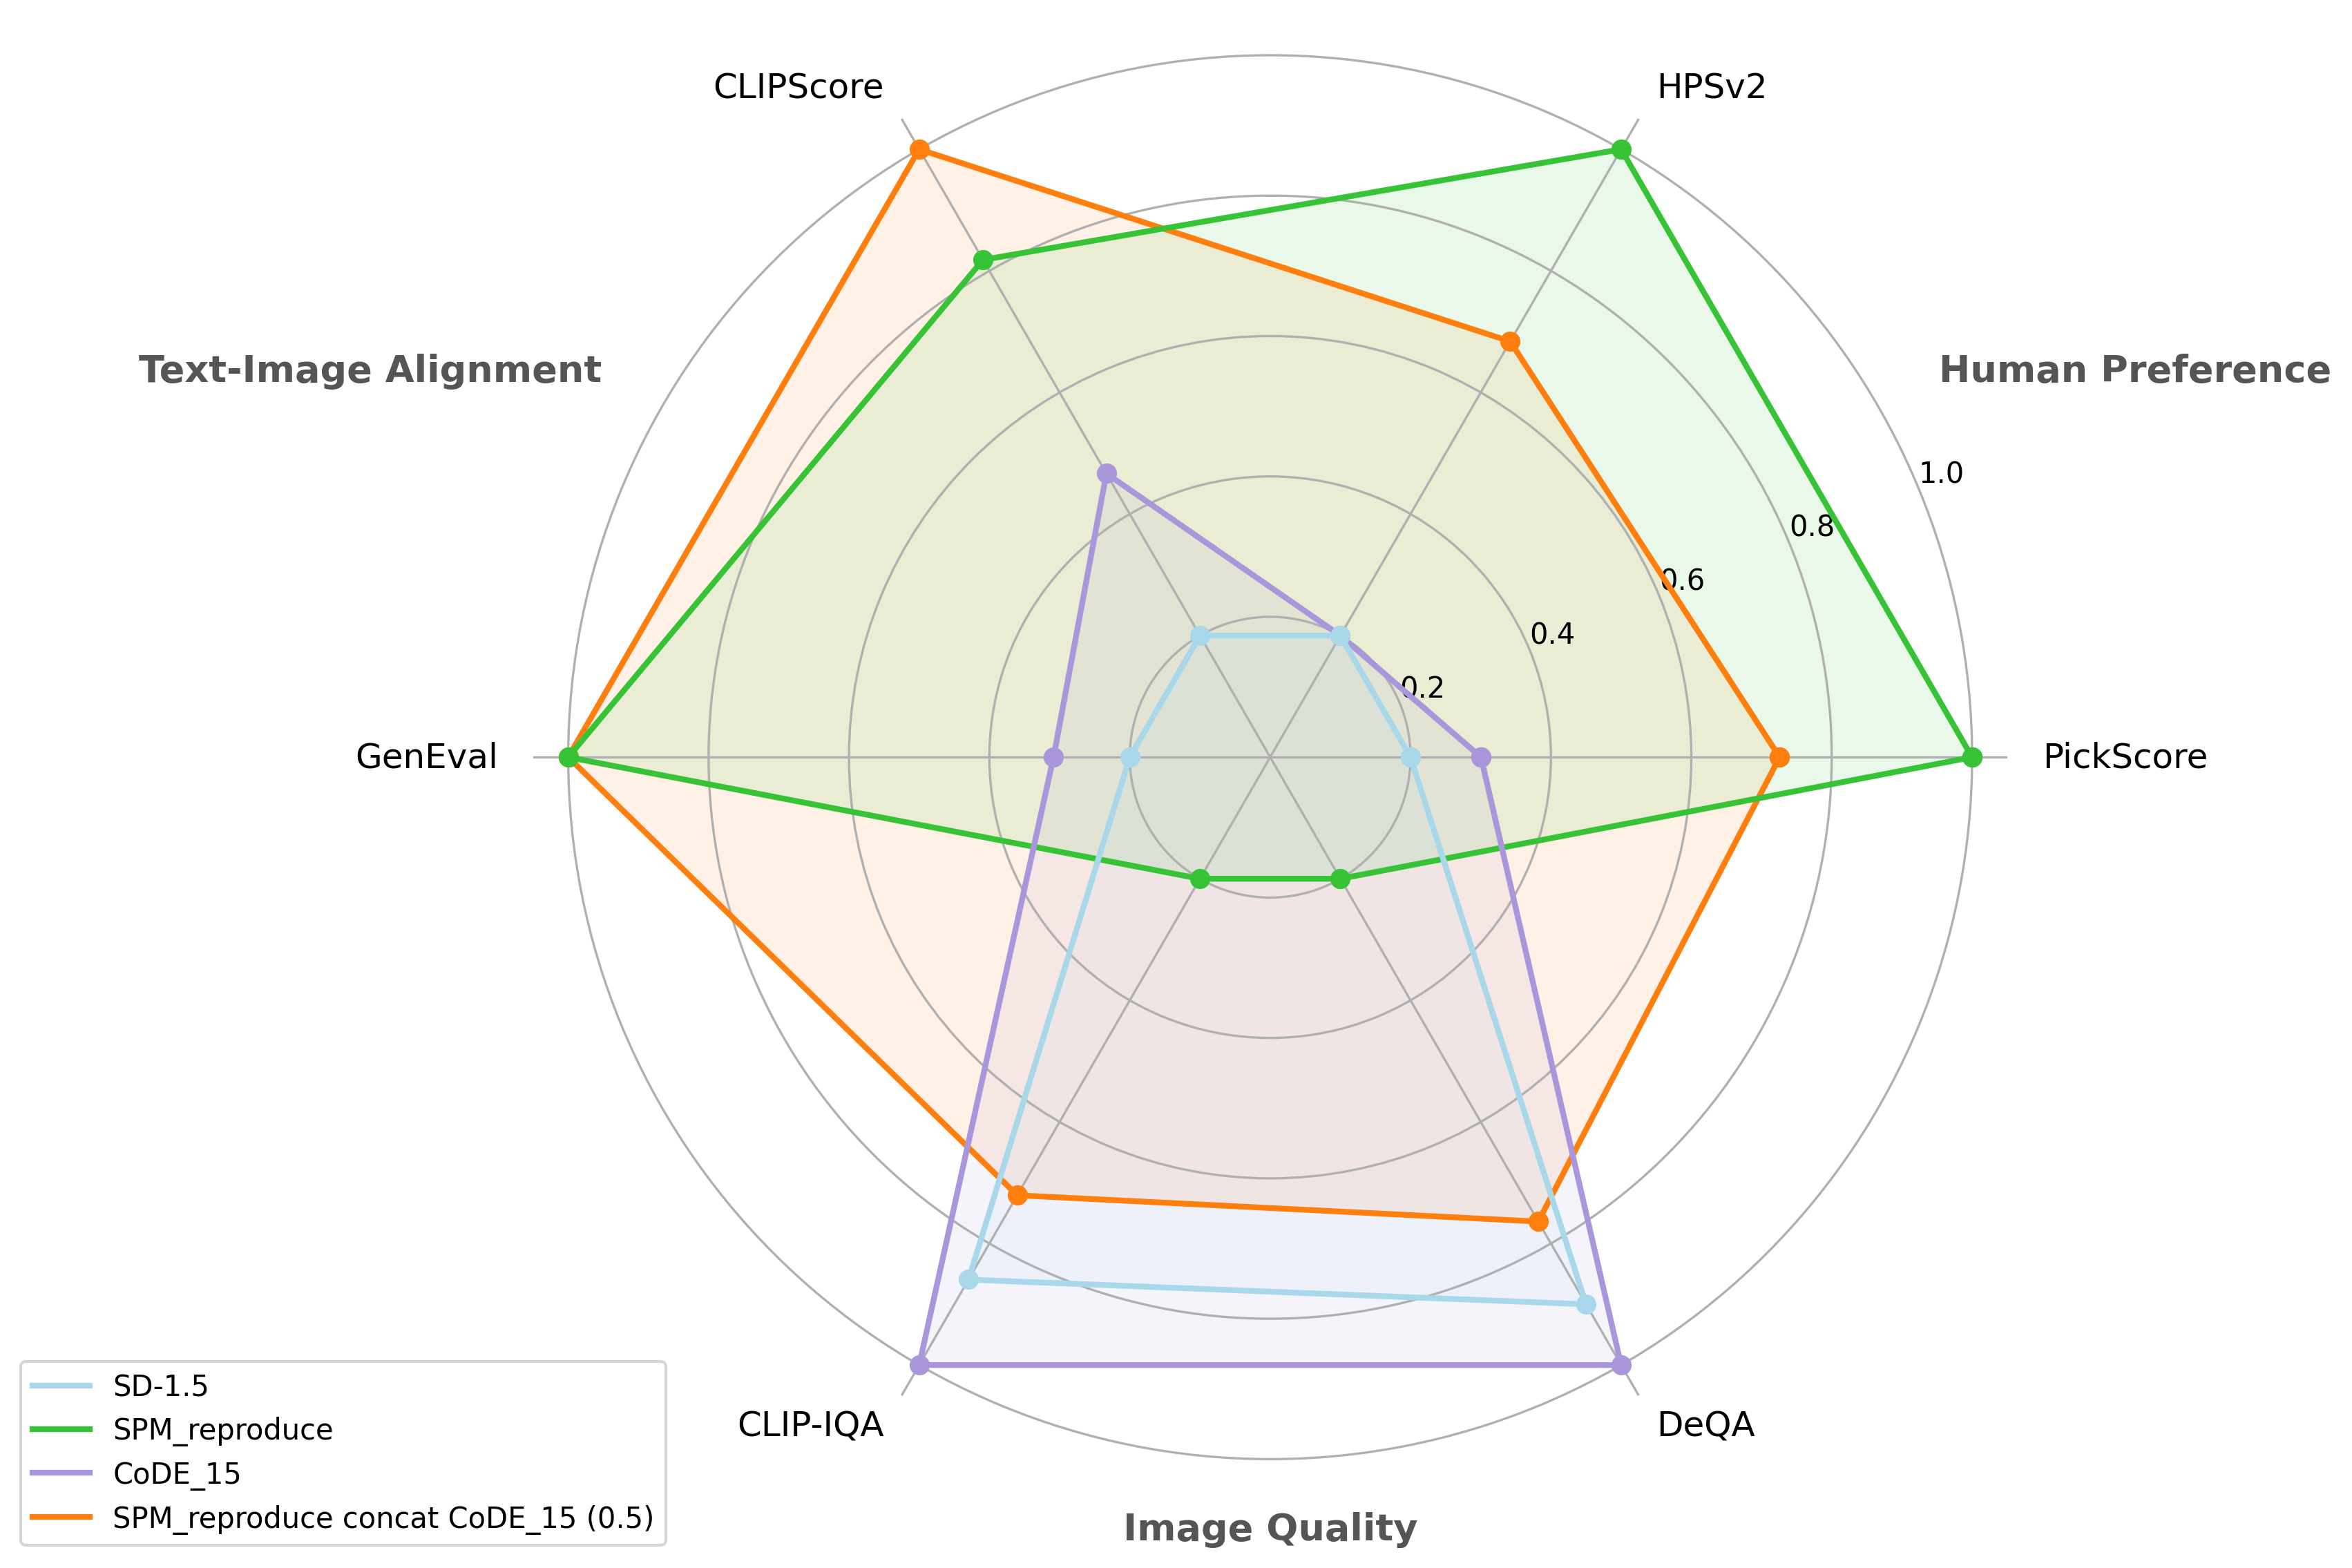

In [6]:
data = {
    "PickScore": [ data_dict[_]["PickScore"] for _ in methods ],
    "HPSv2": [ data_dict[_]["HPSv2"] for _ in methods ],
    "CLIPScore": [ data_dict[_]["CLIPScore"] for _ in methods ],
    "GenEval": [ data_dict[_]["GenEval"] for _ in methods ],
    "CLIP-IQA": [ data_dict[_]["CLIP-IQA"] for _ in methods ],
    "DeQA": [ data_dict[_]["DeQA"] for _ in methods ]
}

min_scale = 0.2

normalized_data = {}
for metric in metrics:
    metric_min, metric_max = min(data[metric]), max(data[metric])
    if metric_max == metric_min:
        normalized_data[metric] = [min_scale + (1-min_scale) * 0.5 for x in data[metric]]
    else:
        normalized_data[metric] = [min_scale + (1-min_scale)*((x-metric_min)/(metric_max-metric_min)) for x in data[metric]]

df = pd.DataFrame(normalized_data, index=methods)

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]  # 闭合雷达图

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(polar=True), dpi=300)

colors = ['#a8d8ea', "#36c436", '#aa96da', '#ff7f0e']
color_map = dict(zip(methods, colors))

# --- 新增代码：根据面积排序来解决覆盖问题 ---
# 1. 计算每个方法归一化分数的总和，作为其“面积”的代表
method_areas = {method: df.loc[method].sum() for method in methods}
# 2. 根据面积从大到小对方法进行排序
sorted_methods = sorted(method_areas, key=method_areas.get, reverse=True)

# --- 修改后的绘图循环：使用排序后的列表 ---
for i, method in enumerate(sorted_methods):
    alpha=0.1
    values = df.loc[method].values.tolist()
    values += values[:1]  # 闭合雷达图
    color = color_map[method] # 使用映射获取正确的颜色
    ax.plot(angles, values, 'o-', linewidth=2, label=method, color=color)
    if i == len(method) - 1:
        alpha=0.3
    ax.fill(angles, values, alpha=alpha, color=color)

# 设置雷达图的轴标签（指标名称）
ax.set_xticks(angles[:-1])
ax.set_xticklabels([])
ax.set_ylim(0, 1.05)

# Manually add labels at a greater distance and with rotation
for i, metric in enumerate(metrics):
    angle_rad = angles[i]
    label_distance = 1.1

    angle_deg = np.degrees(angle_rad)

    if angle_deg > 90 and angle_deg < 270:
        rotation_angle = 0
        ha = 'right'
    else:
        rotation_angle = 0
        ha = 'left'
        
    ax.text(angle_rad, label_distance, metric,
            ha=ha, va='center',
            fontsize=12,
            rotation=rotation_angle,
            rotation_mode="anchor")

# Add category labels
# Define the categories and their positions
categories = {
    "Human Preference": (angles[0] + angles[1]) / 2,  # Between PickScore and HPSv2
    "Text-Image Alignment": (angles[2] + angles[3]) / 2,  # Between CLIPScore and GenEval
    "Image Quality": (angles[4] + angles[5]) / 2,  # Between CLIP-IQA and DeQA
}

# Add category labels in a circular arc outside the metric labels
for category, angle_rad in categories.items():
    label_distance = 1.1  # Further out than metric labels
    angle_deg = np.degrees(angle_rad)
    
    if angle_deg > 90 and angle_deg < 270:
        rotation_angle = 0
        ha = 'right'
    else:
        rotation_angle = 0
        ha = 'left'
    
    if category == "Image Quality":
        ha = 'center'
    ax.text(angle_rad, label_distance, category,
            ha=ha, va='center',
            fontsize=13,
            fontweight='bold',
            color='#555555',
            rotation=rotation_angle,
            rotation_mode='anchor')


legend_handles = [Line2D([0], [0], color=color_map[m], lw=2, label=m) for m in methods]
ax.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(0.1, 0.1))


ax.grid(True)
ax.spines['polar'].set_visible(False)

plt.tight_layout()
plt.show()